Loading the data and Exploring the data 

In [34]:
import pandas as pd 
import numpy as np 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [35]:
crime = pd.read_csv(r'C:\Users\damia\OneDrive\Desktop\DTSC 2301 Folder\Project 3 Crime Data\Crime_Data_from_2020_to_2024 (1).csv')
crime = crime.sample(n=50000, random_state=42).reset_index(drop=True)
crime = crime.sample(n=50000, random_state=42).reset_index(drop=True)

In [36]:
crime.shape

(50000, 28)

In [37]:
crime.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [38]:
crime.isnull().sum()

DR_NO                 0
Date Rptd             0
DATE OCC              0
TIME OCC              0
AREA                  0
AREA NAME             0
Rpt Dist No           0
Part 1-2              0
Crm Cd                0
Crm Cd Desc           0
Mocodes            7572
Vict Age              0
Vict Sex           7189
Vict Descent       7191
Premis Cd             0
Premis Desc          23
Weapon Used Cd    33579
Weapon Desc       33579
Status                0
Status Desc           0
Crm Cd 1              0
Crm Cd 2          46614
Crm Cd 3          49888
Crm Cd 4          49998
LOCATION              0
Cross Street      42292
LAT                   0
LON                   0
dtype: int64

NOTE: we have  couple of null vaules in some of the categories 

In [39]:
crime.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,232107239,03/27/2023 12:00:00 AM,03/24/2023 12:00:00 AM,2006,21,Topanga,2156,1,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),...,AA,Adult Arrest,442.0,NaN,NaN,NaN,VICTORY BL,OWENSMOUTH AV,34.1877,-118.6015
1,211905232,02/04/2021 12:00:00 AM,02/04/2021 12:00:00 AM,515,19,Mission,1983,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,15300 ROSCOE BL,NaN,34.2249,-118.4637
2,230116336,07/19/2023 12:00:00 AM,07/18/2023 12:00:00 AM,2000,1,Central,135,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,IC,Invest Cont,740.0,NaN,NaN,NaN,W 3RD ST,S SPRING,34.0503,-118.2470
3,231007354,03/27/2023 12:00:00 AM,03/27/2023 12:00:00 AM,1300,10,West Valley,1001,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,AO,Adult Other,626.0,NaN,NaN,NaN,7700 MELVIN AV,NaN,34.2103,-118.5603
4,231708993,04/29/2023 12:00:00 AM,04/29/2023 12:00:00 AM,1430,17,Devonshire,1709,2,624,BATTERY - SIMPLE ASSAULT,...,IC,Invest Cont,624.0,NaN,NaN,NaN,15600 ODYSSEY DR,NaN,34.2827,-118.4694


In [40]:
crime.drop(["Part 1-2"], axis=1, inplace=True)

In [41]:
crime.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Mocodes,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,232107239,03/27/2023 12:00:00 AM,03/24/2023 12:00:00 AM,2006,21,Topanga,2156,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),0325,...,AA,Adult Arrest,442.0,NaN,NaN,NaN,VICTORY BL,OWENSMOUTH AV,34.1877,-118.6015
1,211905232,02/04/2021 12:00:00 AM,02/04/2021 12:00:00 AM,515,19,Mission,1983,510,VEHICLE - STOLEN,NaN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,15300 ROSCOE BL,NaN,34.2249,-118.4637
2,230116336,07/19/2023 12:00:00 AM,07/18/2023 12:00:00 AM,2000,1,Central,135,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329 1300 1307 1609,...,IC,Invest Cont,740.0,NaN,NaN,NaN,W 3RD ST,S SPRING,34.0503,-118.2470
3,231007354,03/27/2023 12:00:00 AM,03/27/2023 12:00:00 AM,1300,10,West Valley,1001,626,INTIMATE PARTNER - SIMPLE ASSAULT,0913 2000 1813 0400 0416,...,AO,Adult Other,626.0,NaN,NaN,NaN,7700 MELVIN AV,NaN,34.2103,-118.5603
4,231708993,04/29/2023 12:00:00 AM,04/29/2023 12:00:00 AM,1430,17,Devonshire,1709,624,BATTERY - SIMPLE ASSAULT,0913 1817 2021 0416 0419,...,IC,Invest Cont,624.0,NaN,NaN,NaN,15600 ODYSSEY DR,NaN,34.2827,-118.4694


Create a Is Violent Columns (Classfying our data)

In [42]:
VIOLENT_CRIME_CODES = {110, 
                       113,
                        121, 
                        122, 
                        210, 
                        220, 
                        230, 
                        231,
                        235,
                        236,
                        250,
                        251,
                        434,
                        435,
                        436,
                        622,
                        623,
                        624,
                        625,
                        626,
                        627,
                        648,
                        753,
                        760,
                        805,
                        810,
                        812,
                        815,
                        820,
                        821,
                        822,
                        860,
                        910,
                        920,
                        921,
                        922,
                        940}

In [43]:
crime["Is_Violent"] = crime["Crm Cd"].isin(VIOLENT_CRIME_CODES).astype(int)

In [44]:
crime["Is_Violent"].value_counts()
crime["Is_Violent"].value_counts(normalize=True)

Is_Violent
0    0.7343
1    0.2657
Name: proportion, dtype: float64

# Clean and Preprocess the Data 

In [45]:
# Filter out placeholder ages (0= unkonwn in this dataset) 
crime=crime[crime["Vict Age"]>0]

In [46]:
# TIme OCC is an intger, needs to be converted to hours 
crime["Hour"]=crime["TIME OCC"]//100

# Vizulizations 

In [47]:

crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime["Day_of_Week"] = crime["DATE OCC"].dt.dayofweek
crime["Month"] = crime["DATE OCC"].dt.month

crime["Vict Sex"] = LabelEncoder().fit_transform(crime["Vict Sex"].astype(str))

features = ["Hour", "Day_of_Week", "Month", "AREA", "Vict Age", "Vict Sex"]
target = "Is_Violent"

X = crime[features]
y = crime[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y = crime[target]





C:\Users\damia\AppData\Local\Temp\ipykernel_34496\2584637714.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")


Logistic Regression 

In [48]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [49]:
print(classification_report(y_test,y_pred))
print (confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      1.00      0.80      4852
           1       0.67      0.00      0.00      2482

    accuracy                           0.66      7334
   macro avg       0.66      0.50      0.40      7334
weighted avg       0.66      0.66      0.53      7334

[[4850    2]
 [2478    4]]


# Desicion Tree and Random Forrest 

In [50]:
## Descion Tree
clf = DecisionTreeClassifier(max_depth= 3, random_state=42)
clf.fit(X_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [51]:
clf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(7334,))

In [52]:
rf_model= RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

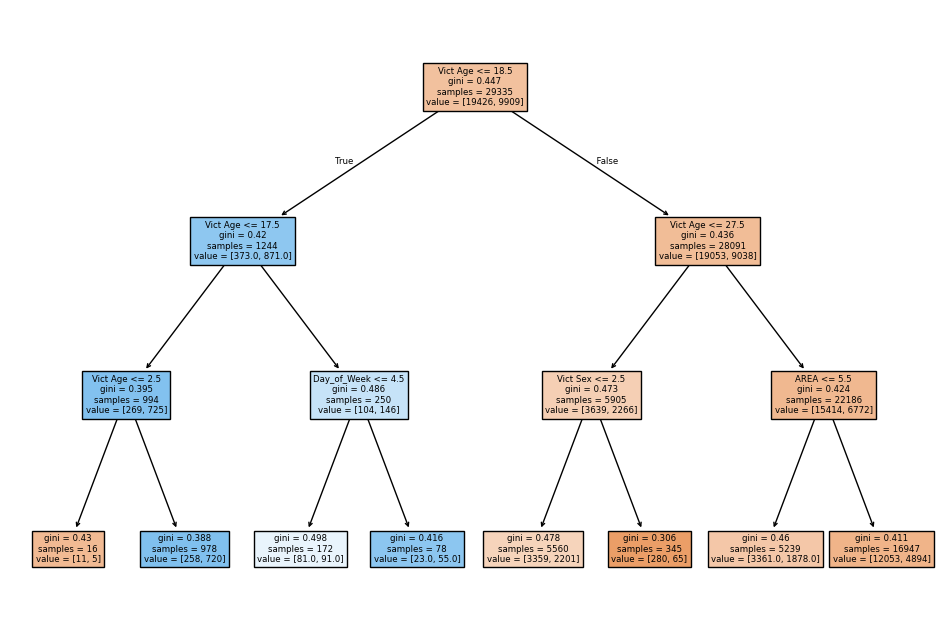

In [53]:
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=features)
plt.show()

# K-Means Clustering 

In [54]:
predictions = rf_model.predict(X_test)

In [55]:
print(f"Accuracy: {accuracy_score(y_test, predictions)}")

Accuracy: 0.6551677120261794


In [56]:
from sklearn.cluster import MiniBatchKMeans

coords = crime[["LAT", "LON"]].dropna()

ss_scores = []
K_range = range(2, 11)

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    
    ss = silhouette_score(coords, labels, sample_size=10000)
    ss_scores.append(ss)

In [57]:
km_performance=pd.DataFrame({
    "K":list(K_range),  # Fixed: k_range -> K_range, wrapped in list()
    "Silhouette Score": ss_scores  # Fixed: ss_values -> ss_scores
})

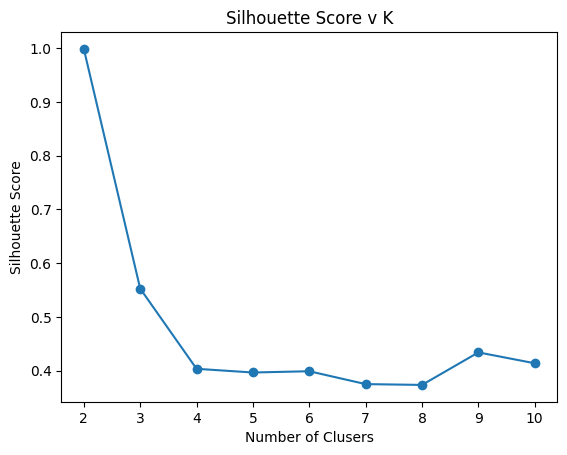

In [58]:
plt.plot(K_range,ss_scores,marker="o")
plt.title("Silhouette Score v K")
plt.xlabel("Number of Clusers")
plt.ylabel("Silhouette Score")
plt.show()

# km= KMeans(n_clusters=5,random_state=42,n_init=10)
# crime.loc[coords.index, "Cluster"] = km.fit_predict(coords)

# plt.scatter(crime["LON"], crime["LAT"], c=crime["Cluster"], cmap="tab10", s=0.5, alpha=0.3)
# plt.title("Crime Clusters in Los Angles")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

In [59]:
print(coords.shape)
print(coords.head())
print(coords.isnull().sum())

(36669, 2)
       LAT       LON
2  34.0503 -118.2470
3  34.2103 -118.5603
4  34.2827 -118.4694
6  33.9487 -118.3972
7  33.9678 -118.2871
LAT    0
LON    0
dtype: int64


In [60]:
best_k = km_performance.sort_values(by="Silhouette Score", ascending=False).iloc[0]["K"]  # Fixed: column name & removed .astype(int)
best_k = int(best_k)
print("The best K is", best_k)

The best K is 2


In [61]:
# Final Clustering

# Create a new KMeans model using the best value of k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Create labels variable using fit_predict on coords
labels = km_final.fit_predict(coords)


c:\Users\damia\OneDrive\Desktop\DTSC 2301 Folder\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


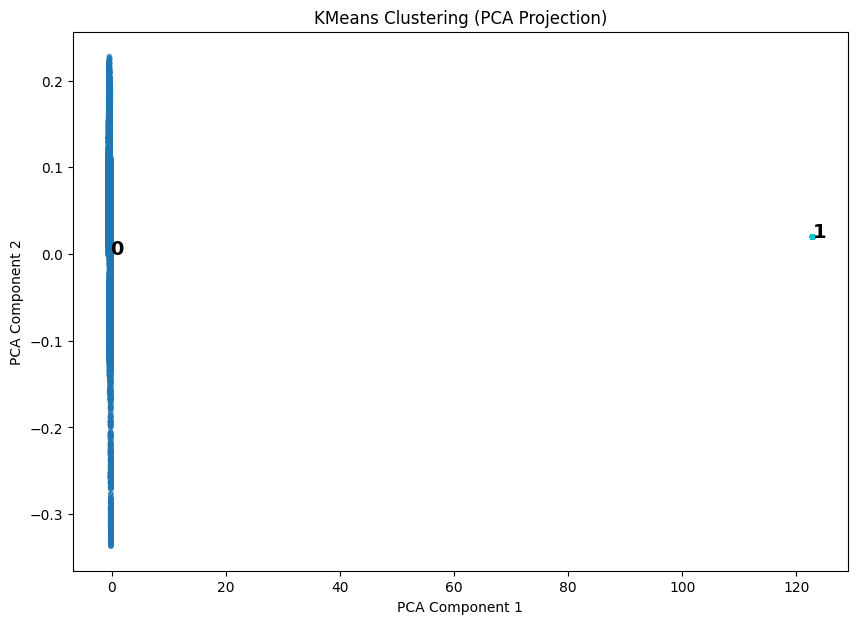

In [62]:
from sklearn.decomposition import PCA
# Create a visual representation of KMeans Clustering

# Initialize PCA with n_components=2
pca = PCA(n_components=2)

# Fit and transform coords using fit_transform()
X_pca = pca.fit_transform(coords)

# Transform cluster centers using pca to create centers_pca
centers_pca = pca.transform(km_final.cluster_centers_)

# Create a scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, alpha=0.4, s=10, cmap="tab10")
plt.title("KMeans Clustering (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Add cluster numbers at the center of each cluster
for i, center in enumerate(centers_pca):
    plt.text(center[0], center[1], str(i), fontsize=14, weight="bold", color="black")

plt.show()

In [63]:
print(type(coords))
print(type(km_final))

<class 'pandas.core.frame.DataFrame'>
<class 'sklearn.cluster._kmeans.KMeans'>
